# Comparativa de algoritmos de descenso

En el siguiente programa se realiza una comparativa entre los algoritmos de descenso estudiados en el trabajo. El ejemplo consiste en un ajuste de regresión lineal bidimensional mal condicionado, en el que los valores de la segunda variable son muy superiores a los de la primera.

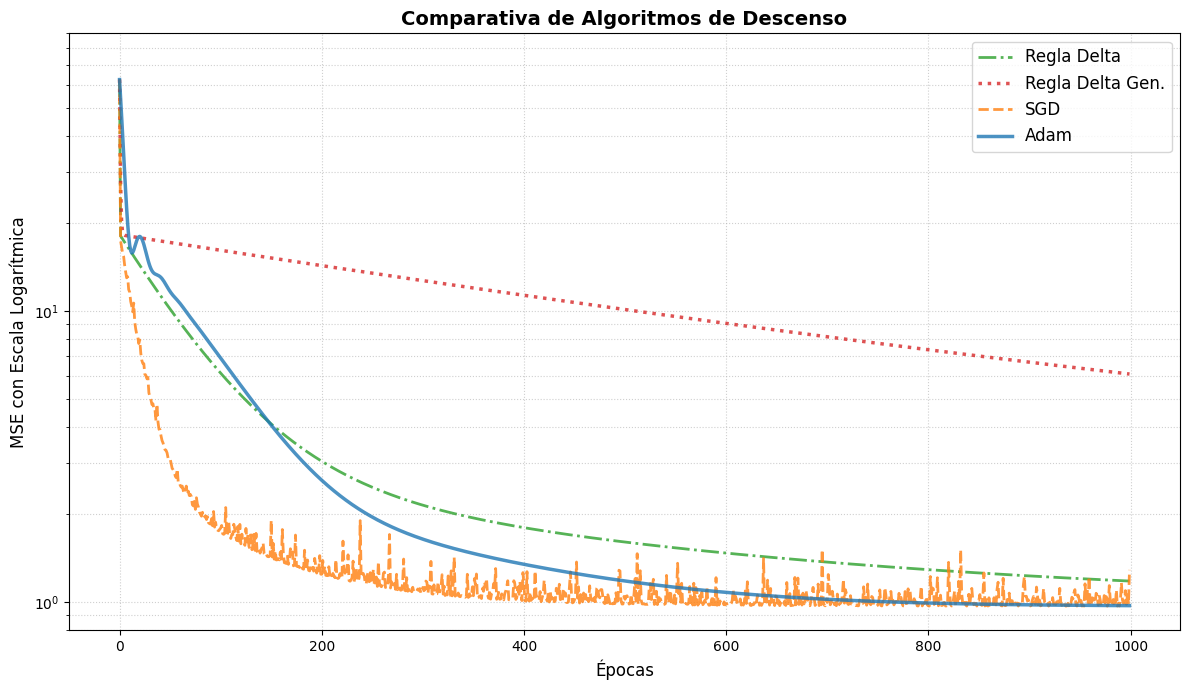

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generación de datos mal condicionados
np.random.seed(42)

# X1 es pequeño, X2 es enorme
X1 = np.random.rand(200, 1) * 2
X2 = np.random.rand(200, 1) * 40

X = np.c_[X1, X2]

# Recta real
y = 5 + 3 * X1 + 0.5 * X2 + np.random.randn(200, 1)

X_b = np.c_[np.ones((200, 1)), X]

# Configuracion de entrenamiento
epochs = 1000
m_samples = len(X_b)
learning_rate = 0.005

# Pesos iniciales
W_init = np.random.randn(3, 1)
loss_history = {}

# Funcion de perdida MSE
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)


# Regla Delta
W = W_init.copy()
losses = []
lr_delta = learning_rate / 100 # Bajamos la tasa de aprendizaje

for epoch in range(epochs):
    losses.append(mse_loss(y, X_b.dot(W)))
    for i in range(m_samples):
        xi = X_b[i:i+1]
        yi = y[i:i+1]
        prediction = xi.dot(W)
        W += lr_delta * (yi - prediction) * xi.T
loss_history['Regla Delta'] = losses


# Regla Delta Generalizada
W = W_init.copy()
losses = []
lr_bgd = learning_rate / 10

for epoch in range(epochs):
    predictions = X_b.dot(W)
    losses.append(mse_loss(y, predictions))
    gradient = (2/m_samples) * X_b.T.dot(predictions - y)
    W -= lr_bgd * gradient
loss_history['Regla Delta Gen.'] = losses


# Descenso de Gradiente Estocástico
W = W_init.copy()
losses = []
lr_sgd = learning_rate / 50

for epoch in range(epochs):
    losses.append(mse_loss(y, X_b.dot(W)))
    shuffled_indices = np.random.permutation(m_samples)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]

    for i in range(m_samples):
        xi = X_b_shuffled[i:i+1]
        yi = y_shuffled[i:i+1]
        prediction = xi.dot(W)
        gradient = 2 * xi.T.dot(prediction - yi)
        W -= lr_sgd * gradient
loss_history['SGD'] = losses


# Adam
W = W_init.copy()
losses = []
m = np.zeros((3, 1))
v = np.zeros((3, 1))
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8

for epoch in range(epochs):
    predictions = X_b.dot(W)
    losses.append(mse_loss(y, predictions))
    gradients = (2/m_samples) * X_b.T.dot(predictions - y)

    m = beta1 * m + (1 - beta1) * gradients
    v = beta2 * v + (1 - beta2) * (gradients**2)
    m_hat = m / (1 - beta1**(epoch + 1))
    v_hat = v / (1 - beta2**(epoch + 1))

    W -= (learning_rate * 5) * m_hat / (np.sqrt(v_hat) + epsilon)
loss_history['Adam'] = losses




# Visualización
plt.figure(figsize=(12, 7))
estilos = {
    'Adam': {'color': '#1f77b4', 'linestyle': '-', 'linewidth': 2.5},
    'SGD': {'color': '#ff7f0e', 'linestyle': '--', 'linewidth': 2},
    'Regla Delta': {'color': '#2ca02c', 'linestyle': '-.', 'linewidth': 2},
    'Regla Delta Gen.': {'color': '#d62728', 'linestyle': ':', 'linewidth': 2.5}
}

for name, loss_values in loss_history.items():
    plt.plot(range(epochs), loss_values, label=name,
             color=estilos[name]['color'],
             linestyle=estilos[name]['linestyle'],
             linewidth=estilos[name]['linewidth'], alpha=0.8)

plt.yscale('log')
plt.ylim(bottom=0.8, top=90)

plt.title('Comparativa de Algoritmos de Descenso', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('MSE con Escala Logarítmica', fontsize=12)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, which="both", linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()